# Find the shapes inscribed in other shape using algorithms and it should be powerful enough to classify 


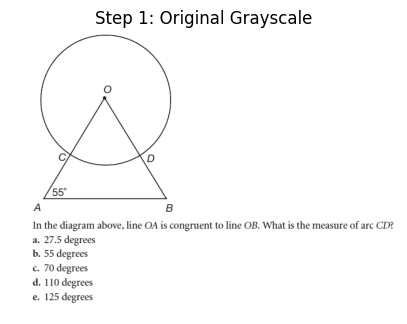

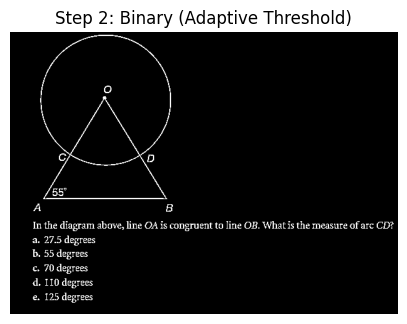

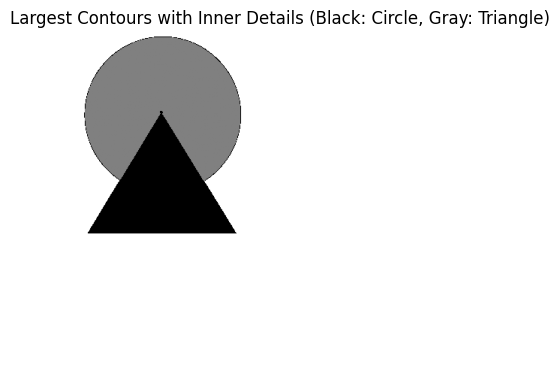

Largest contour area: 43471.0, Second largest: 27097.5


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title("Step 1: Original Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step1_grayscale.png", image)

    binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 9, 3)
    plt.figure(figsize=(5, 5))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 2: Binary (Adaptive Threshold)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step2_binary.png", binary)

    return binary

def detect_largest_contour(image_path):
    edges = preprocess_image(image_path)

    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print("No contours found.")
        return

    # Sort contours by area and get the two largest
    valid_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]

    if len(valid_contours) < 1:
        print("No valid contours found.")
        return

    # Create a blank image with white background
    outline_image = np.ones_like(edges) * 255  # White background

    # Fill the largest contour (likely circle) with black
    cv2.fillPoly(outline_image, [valid_contours[0]], 0)  # Black for circle

    # Fill the second largest contour (likely triangle) with gray
    if len(valid_contours) > 1:
        cv2.fillPoly(outline_image, [valid_contours[1]], 128)  # Gray for triangle

    plt.figure(figsize=(6, 6))
    plt.imshow(outline_image, cmap='gray')
    plt.title("Largest Contours with Inner Details (Black: Circle, Gray: Triangle)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("largest_contours_with_inner_details.png", outline_image)

    print(f"Largest contour area: {cv2.contourArea(valid_contours[0])}, Second largest: {cv2.contourArea(valid_contours[1]) if len(valid_contours) > 1 else 'None'}")

image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\048.png"
detect_largest_contour(image_path)

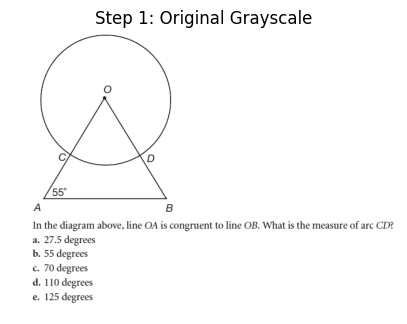

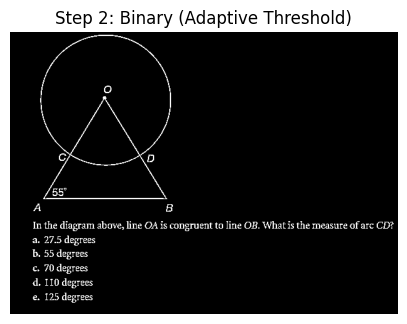

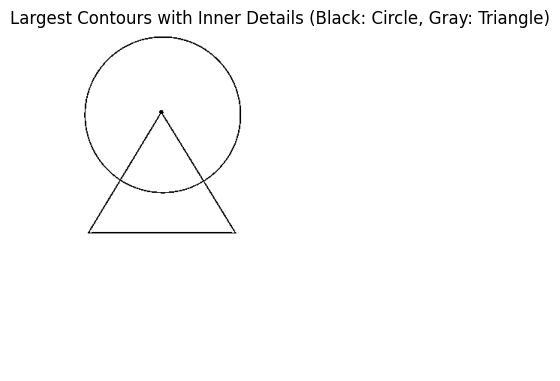

Largest contour size: 2157, Second largest: None


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title("Step 1: Original Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step1_grayscale.png", image)

    binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 9, 3)
    plt.figure(figsize=(5, 5))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 2: Binary (Adaptive Threshold)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step2_binary.png", binary)

    return binary

def find_contours_manual(binary):
    height, width = binary.shape
    visited = np.zeros((height, width), dtype=bool)
    contours = []

    def edge_follow(x, y):
        contour = []
        stack = [(x, y)]
        while stack:
            cx, cy = stack.pop()
            if (0 <= cx < height and 0 <= cy < width and 
                not visited[cx, cy] and binary[cx, cy] == 255):
                visited[cx, cy] = True
                contour.append((cx, cy))
                # Check all 8 neighbors for a more complete contour
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0:
                            continue
                        nx, ny = cx + dx, cy + dy
                        if (0 <= nx < height and 0 <= ny < width and 
                            not visited[nx, ny] and binary[nx, ny] == 255):
                            stack.append((nx, ny))
        return contour

    for i in range(height):
        for j in range(width):
            if binary[i, j] == 255 and not visited[i, j]:
                contour = edge_follow(i, j)
                if len(contour) > 200:  # Minimum size to filter noise
                    contours.append(contour)

    # Sort contours by area (number of points)
    contours.sort(key=len, reverse=True)
    return contours[:4]  # Return top 2 largest contours

def detect_largest_contour(image_path):
    binary = preprocess_image(image_path)

    contours = find_contours_manual(binary)
    if not contours:
        print("No contours found.")
        return

    if len(contours) < 1:
        print("No valid contours found.")
        return

    # Create a blank image with white background
    outline_image = np.ones_like(binary) * 255  # White background

    # Fill the largest contour (likely circle) with black
    if contours[0]:
        coords = np.array(contours[0], dtype=np.int32)
        outline_image[coords[:, 0], coords[:, 1]] = 0  # Fill with black

    # Fill the second largest contour (likely triangle) with gray
    if len(contours) > 1 and contours[1]:
        coords = np.array(contours[1], dtype=np.int32)
        outline_image[coords[:, 0], coords[:, 1]] = 128  # Fill with gray

    plt.figure(figsize=(6, 6))
    plt.imshow(outline_image, cmap='gray')
    plt.title("Largest Contours with Inner Details (Black: Circle, Gray: Triangle)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("largest_contours_with_inner_details.png", outline_image)

    print(f"Largest contour size: {len(contours[0])}, Second largest: {len(contours[1]) if len(contours) > 1 else 'None'}")

image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\048.png"
detect_largest_contour(image_path)

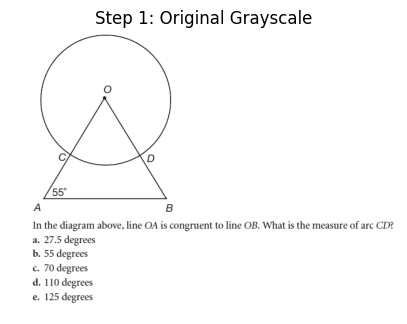

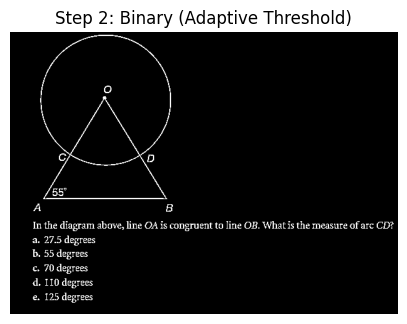

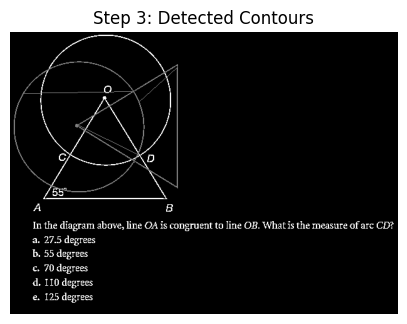

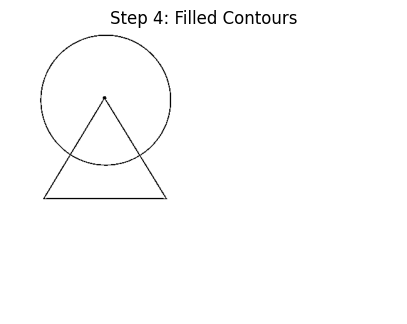

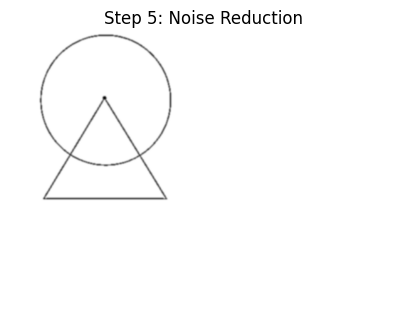

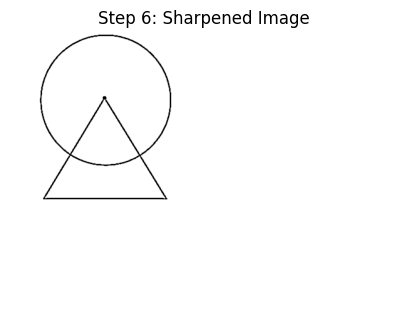

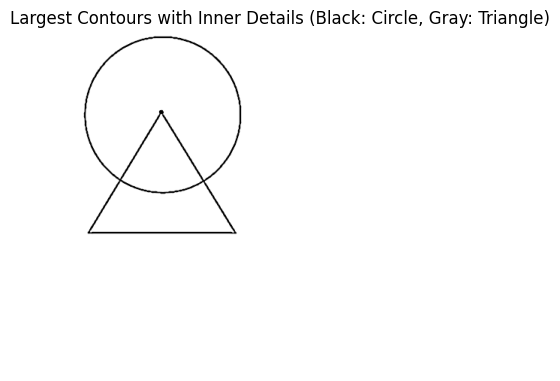

Largest contour size: 2157, Second largest: None


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    plt.figure(figsize=(5, 5))
    plt.imshow(image, cmap='gray')
    plt.title("Step 1: Original Grayscale")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step1_grayscale.png", image)

    binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 9, 3)
    plt.figure(figsize=(5, 5))
    plt.imshow(binary, cmap='gray')
    plt.title("Step 2: Binary (Adaptive Threshold)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step2_binary.png", binary)

    return binary

def find_contours_manual(binary):
    height, width = binary.shape
    visited = np.zeros((height, width), dtype=bool)
    contours = []

    def edge_follow(x, y):
        contour = []
        stack = [(x, y)]
        while stack:
            cx, cy = stack.pop()
            if (0 <= cx < height and 0 <= cy < width and 
                not visited[cx, cy] and binary[cx, cy] == 255):
                visited[cx, cy] = True
                contour.append((cx, cy))
                # Check all 8 neighbors for a more complete contour
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0:
                            continue
                        nx, ny = cx + dx, cy + dy
                        if (0 <= nx < height and 0 <= ny < width and 
                            not visited[nx, ny] and binary[nx, ny] == 255):
                            stack.append((nx, ny))
        return contour

    for i in range(height):
        for j in range(width):
            if binary[i, j] == 255 and not visited[i, j]:
                contour = edge_follow(i, j)
                if len(contour) > 200:  # Minimum size to filter noise
                    contours.append(contour)

    # Sort contours by area (number of points)
    contours.sort(key=len, reverse=True)
    return contours[:4]  # Return top 2 largest contours

def detect_largest_contour(image_path):
    binary = preprocess_image(image_path)

    contours = find_contours_manual(binary)
    if not contours:
        print("No contours found.")
        return

    if len(contours) < 1:
        print("No valid contours found.")
        return

    # Step 3: Visualize detected contours on binary image
    contour_image = binary.copy()
    for contour in contours:
        coords = np.array(contour, dtype=np.int32)
        cv2.polylines(contour_image, [coords], isClosed=True, color=128, thickness=1)
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_image, cmap='gray')
    plt.title("Step 3: Detected Contours")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step3_detected_contours.png", contour_image)

    # Step 4: Create and fill contours on a new canvas
    outline_image = np.ones_like(binary) * 255  # White background
    if contours[0]:
        coords = np.array(contours[0], dtype=np.int32)
        outline_image[coords[:, 0], coords[:, 1]] = 0  # Fill with black
    if len(contours) > 1 and contours[1]:
        coords = np.array(contours[1], dtype=np.int32)
        outline_image[coords[:, 0], coords[:, 1]] = 128  # Fill with gray
    plt.figure(figsize=(5, 5))
    plt.imshow(outline_image, cmap='gray')
    plt.title("Step 4: Filled Contours")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step4_filled_contours.png", outline_image)

    # Step 5: Noise Reduction using Gaussian Blur
    noise_reduced = cv2.GaussianBlur(outline_image, (5, 5), 0)
    plt.figure(figsize=(5, 5))
    plt.imshow(noise_reduced, cmap='gray')
    plt.title("Step 5: Noise Reduction")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step5_noise_reduced.png", noise_reduced)

    # Step 6: Sharpen the image
    kernel = np.array([[-1, -1, -1],
                      [-1, 9, -1],
                      [-1, -1, -1]])
    sharpened = cv2.filter2D(noise_reduced, -1, kernel)
    plt.figure(figsize=(5, 5))
    plt.imshow(sharpened, cmap='gray')
    plt.title("Step 6: Sharpened Image")
    plt.axis("off")
    plt.show()
    cv2.imwrite("step6_sharpened.png", sharpened)

    plt.figure(figsize=(6, 6))
    plt.imshow(sharpened, cmap='gray')
    plt.title("Largest Contours with Inner Details (Black: Circle, Gray: Triangle)")
    plt.axis("off")
    plt.show()
    cv2.imwrite("largest_contours_with_inner_details.png", sharpened)

    print(f"Largest contour size: {len(contours[0])}, Second largest: {len(contours[1]) if len(contours) > 1 else 'None'}")

image_path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\048.png"
detect_largest_contour(image_path)

## Both processing and then classifying if its inscribed 

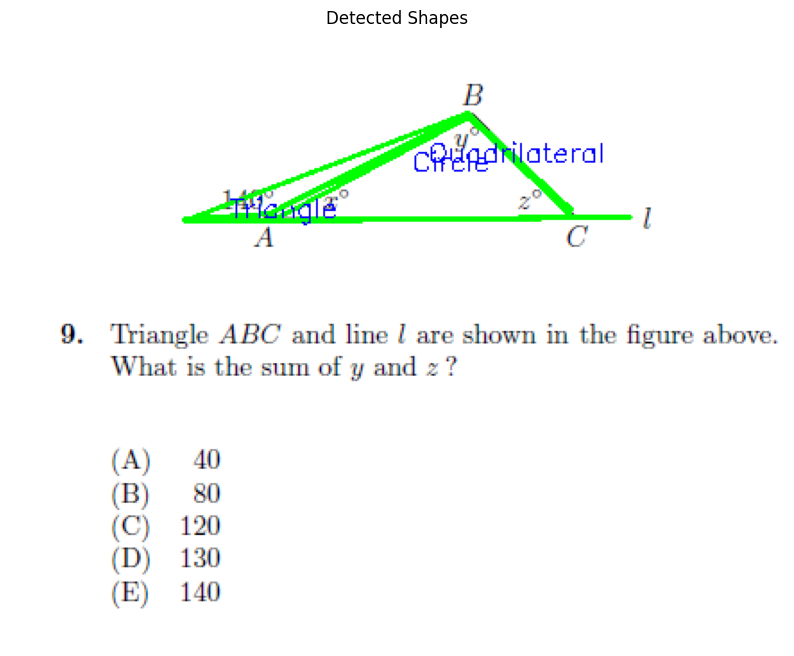

Detected Shapes: Circle, Quadrilateral


In [21]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

def preprocess_image(path):
    """Preprocess the image to enhance shape detection"""
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found at {path}")

    # Apply adaptive threshold to get binary image
    binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY_INV, 9, 3)
    
    # Find and process contours manually
    height, width = binary.shape
    visited = np.zeros((height, width), dtype=bool)
    contours = []

    def edge_follow(x, y):
        contour = []
        stack = [(x, y)]
        while stack:
            cx, cy = stack.pop()
            if (0 <= cx < height and 0 <= cy < width and 
                not visited[cx, cy] and binary[cx, cy] == 255):
                visited[cx, cy] = True
                contour.append((cx, cy))
                # Check all 8 neighbors for a more complete contour
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0:
                            continue
                        nx, ny = cx + dx, cy + dy
                        if (0 <= nx < height and 0 <= ny < width and 
                            not visited[nx, ny] and binary[nx, ny] == 255):
                            stack.append((nx, ny))
        return contour

    for i in range(height):
        for j in range(width):
            if binary[i, j] == 255 and not visited[i, j]:
                contour = edge_follow(i, j)
                if len(contour) > 200:  # Minimum size to filter noise
                    contours.append(contour)

    # Sort contours by area (number of points)
    contours.sort(key=len, reverse=True)
    contours = contours[:4]  # Return top 4 largest contours

    # Create and fill contours on a new canvas
    outline_image = np.ones_like(binary) * 255  # White background
    for idx, contour in enumerate(contours):
        if contour:
            coords = np.array(contour, dtype=np.int32)
            # Use different grayscale values for different contours
            outline_image[coords[:, 0], coords[:, 1]] = 255 - (idx + 1) * 60

    # Noise Reduction using Gaussian Blur
    noise_reduced = cv2.GaussianBlur(outline_image, (5, 5), 0)
    
    # Sharpen the image
    kernel = np.array([[-1, -1, -1],
                      [-1, 9, -1],
                      [-1, -1, -1]])
    sharpened = cv2.filter2D(noise_reduced, -1, kernel)
    
    # Save only the final processed image
    cv2.imwrite("processed_contours.png", sharpened)
    
    return sharpened

def detect_shapes(preprocessed_image, original_image_path):
    '''
    Detect shapes in the preprocessed image
    
    '''
    # Convert preprocessed image to edges
    edges = cv2.Canny(preprocessed_image.astype(np.uint8), 50, 150)
    
    # Load original image for visualization
    original = cv2.imread(original_image_path)
    if original is None:
        original = np.zeros((preprocessed_image.shape[0], preprocessed_image.shape[1], 3), dtype=np.uint8)
    
    # Find contours
    contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        print("No contours found!")
        return "No shapes detected"
    
    if hierarchy is None:
        print("No hierarchy returned!")
        return "No shapes detected"
    
    # Simplify the hierarchy array
    hierarchy = hierarchy[0]
    
    shapes = []
    detected_shapes = []
    
    # Loop through contours
    for i, cnt in enumerate(contours):
        # Filter small contours
        if cv2.contourArea(cnt) < 100:
            continue
            
        epsilon = 0.02 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        vertices = len(approx)
        
        M = cv2.moments(cnt)
        if M['m00'] != 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
        else:
            cx, cy = 0, 0
        center = (cx, cy)
        
        area = cv2.contourArea(cnt)
        
        side_lengths = []
        for j in range(vertices):
            p1 = approx[j][0]
            p2 = approx[(j + 1) % vertices][0]
            dist = math.hypot(p2[0] - p1[0], p2[1] - p1[1])
            side_lengths.append(dist)
        
        angles = []
        for j in range(vertices):
            p0 = approx[j - 1][0]
            p1 = approx[j][0]
            p2 = approx[(j + 1) % vertices][0]
            
            v1 = (p0[0] - p1[0], p0[1] - p1[1])
            v2 = (p2[0] - p1[0], p2[1] - p1[1])
            
            dot_prod = v1[0]*v2[0] + v1[1]*v2[1]
            mag1 = math.hypot(v1[0], v1[1])
            mag2 = math.hypot(v2[0], v2[1])
            
            if mag1 == 0 or mag2 == 0:
                angle = 0
            else:
                cos_theta = dot_prod / (mag1 * mag2)
                cos_theta = max(min(cos_theta, 1), -1)
                angle = math.acos(cos_theta) * 180 / math.pi
            
            angles.append(angle)
        
        shape = "Unknown"
        
        if vertices == 3:
            shape = "Triangle"
        elif vertices == 4:
            sides_equal = all(abs(side_lengths[k] - side_lengths[0]) < 5 for k in range(1, 4))
            angles_close_90 = all(abs(a - 90) < 15 for a in angles)
            
            if sides_equal and angles_close_90:
                shape = "Square"
            elif angles_close_90:
                shape = "Rectangle"
            else:
                shape = "Quadrilateral"
        elif vertices == 5:
            shape = "Pentagon"
        
        
        elif vertices > 5:
            shape = "Circle"
        # elif vertices > 4:
        #     (x, y), radius = cv2.minEnclosingCircle(cnt)
        #     circularity = 4 * math.pi * area / (cv2.arcLength(cnt, True) ** 2)
            
        #     if circularity > 0.8:
        #         shape = "Circle"
        #     else:
        #         shape = f"{vertices}-gon"
        


        # Add to shapes list
        parent_idx = hierarchy[i][3]
        shapes.append({
            'index': i,
            'shape': shape,
            'center': center,
            'area': area,
            'parent': parent_idx,
            'contour': approx,
            'sides': side_lengths,
            'angles': angles
        })
        
        # Add to detected_shapes if it's a main shape (not a child or very small)
        if shape not in ["Unknown", "Quadrilateral"] and area > 500:
            if shape not in detected_shapes:
                detected_shapes.append(shape)
        
        # Draw contours and shape names
        cv2.drawContours(original, [approx], -1, (0, 255, 0), 2)
        cv2.putText(original, shape, center, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
    # Check for inscribed shapes
    inscribed_pairs = []
    for s in shapes:
        if s['parent'] != -1:
            try:
                parent = next(p for p in shapes if p['index'] == s['parent'])
                dx = abs(s['center'][0] - parent['center'][0])
                dy = abs(s['center'][1] - parent['center'][1])
                area_ratio = s['area'] / parent['area'] if parent['area'] > 0 else 0
                
                if dx < 20 and dy < 20 and 0.2 < area_ratio < 0.8:
                    inscribed_pairs.append(f"{s['shape']} in {parent['shape']}")
                    if s['shape'] not in detected_shapes:
                        detected_shapes.append(s['shape'])
                    if parent['shape'] not in detected_shapes:
                        detected_shapes.append(parent['shape'])
            except StopIteration:
                continue
    
    # Save the result image
    cv2.imwrite("detected_shapes.png", original)
    
    # Show the result
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Detected Shapes")
    plt.axis("off")
    plt.show()
    
    # Return detected shapes as a string
    if not detected_shapes:
        return "No shapes detected"
    else:
        return f"Detected Shapes: {', '.join(detected_shapes)}"

def imageProcessor(path):
    """
    Process image and detect shapes
    """
    try:
        processed_image = preprocess_image(path) # Preprocess the image
        result = detect_shapes(processed_image, path) # Detect shapes
        print(result)
        return result
    except Exception as e:
        print(f"Error processing image: {e}")
        return f"Error: {e}"

# Example usage
if __name__ == "__main__":
    #path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\048.png"
    path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\013.png"
    imageProcessor(path)

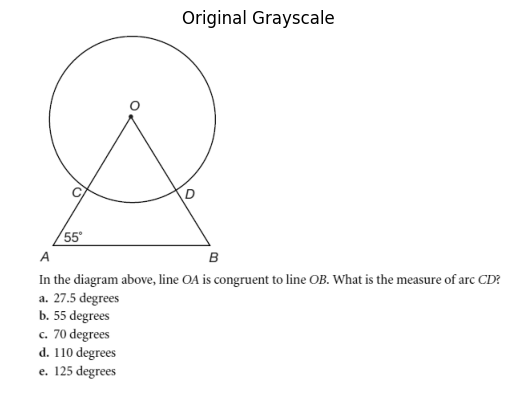

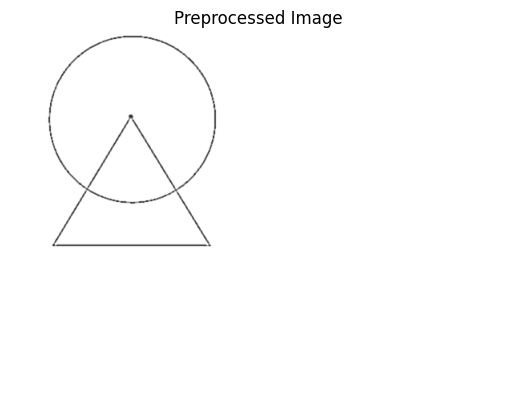

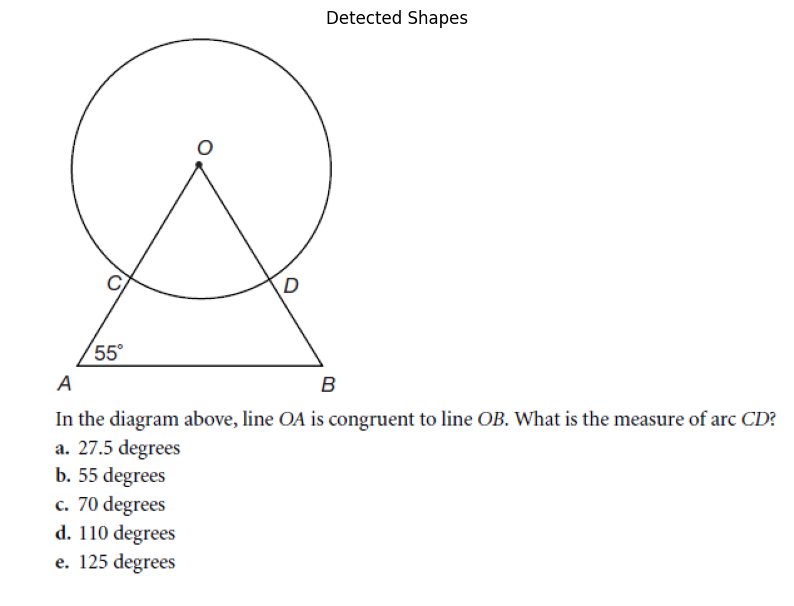

No shapes detected


In [ ]:
#   FIX THE CODE
#   -------------------------------------
#    -------------------------------------
#   -------------------------------------
#    -------------------------------------


import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

def preprocess_image(path, visualize=False):
    """Preprocess the image to enhance shape detection"""
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found at {path}")

    if visualize:
        plt.imshow(image, cmap='gray')
        plt.title("Original Grayscale")
        plt.axis("off")
        plt.show()

    binary = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 9, 3)

    height, width = binary.shape
    visited = np.zeros((height, width), dtype=bool)
    contours = []

    def edge_follow(x, y):
        contour = []
        stack = [(x, y)]
        while stack:
            cx, cy = stack.pop()
            if (0 <= cx < height and 0 <= cy < width and 
                not visited[cx, cy] and binary[cx, cy] == 255):
                visited[cx, cy] = True
                contour.append((cx, cy))
                for dx in [-1, 0, 1]:
                    for dy in [-1, 0, 1]:
                        if dx == 0 and dy == 0:
                            continue
                        nx, ny = cx + dx, cy + dy
                        if (0 <= nx < height and 0 <= ny < width and 
                            not visited[nx, ny] and binary[nx, ny] == 255):
                            stack.append((nx, ny))
        return contour

    for i in range(height):
        for j in range(width):
            if binary[i, j] == 255 and not visited[i, j]:
                contour = edge_follow(i, j)
                if len(contour) > 200:
                    contours.append(contour)

    contours.sort(key=len, reverse=True)
    contours = contours[:4]

    outline_image = np.ones_like(binary) * 255
    for idx, contour in enumerate(contours):
        if contour:
            coords = np.array(contour, dtype=np.int32)
            outline_image[coords[:, 0], coords[:, 1]] = 255 - (idx + 1) * 60

    noise_reduced = cv2.GaussianBlur(outline_image, (5, 5), 0)

    kernel = np.array([[-1, -1, -1],
                       [-1, 9, -1],
                       [-1, -1, -1]])
    sharpened = cv2.filter2D(noise_reduced, -1, kernel)

    if visualize:
        plt.imshow(sharpened, cmap='gray')
        plt.title("Preprocessed Image")
        plt.axis("off")
        plt.show()

    return sharpened


def detect_shapes(preprocessed_image, original_image_path):
    """
    Detect shapes in the preprocessed image with integrated Canny edge detection.
    """

    #MANUAL CANNY 
    def manual_canny(image, low_threshold, high_threshold):
        # 1. Gaussian Blur
        blurred = cv2.GaussianBlur(image, (5, 5), 1.4)

        # 2. Compute Gradients using Sobel filters
        Gx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
        Gy = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

        magnitude = np.hypot(Gx, Gy)
        magnitude = magnitude / magnitude.max() * 255  # Normalize to 0-255
        angle = np.arctan2(Gy, Gx) * 180 / np.pi
        angle[angle < 0] += 180

        # 3. Non-Maximum Suppression
        nms = np.zeros_like(magnitude)
        rows, cols = magnitude.shape
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                try:
                    q, r = 255, 255

                    angle_deg = angle[i, j]

                    if (0 <= angle_deg < 22.5) or (157.5 <= angle_deg <= 180):
                        q = magnitude[i, j+1]
                        r = magnitude[i, j-1]
                    elif (22.5 <= angle_deg < 67.5):
                        q = magnitude[i+1, j-1]
                        r = magnitude[i-1, j+1]
                    elif (67.5 <= angle_deg < 112.5):
                        q = magnitude[i+1, j]
                        r = magnitude[i-1, j]
                    elif (112.5 <= angle_deg < 157.5):
                        q = magnitude[i-1, j-1]
                        r = magnitude[i+1, j+1]

                    if (magnitude[i, j] >= q) and (magnitude[i, j] >= r):
                        nms[i, j] = magnitude[i, j]
                    else:
                        nms[i, j] = 0
                except IndexError:
                    pass

        # 4. Double Thresholding
        high = nms.max() * high_threshold / 255
        low = high * low_threshold / high_threshold

        res = np.zeros_like(nms)
        strong = 255
        weak = 75

        strong_i, strong_j = np.where(nms >= high)
        zeros_i, zeros_j = np.where(nms < low)
        weak_i, weak_j = np.where((nms >= low) & (nms < high))

        res[strong_i, strong_j] = strong
        res[weak_i, weak_j] = weak

        # 5. Edge Tracking by Hysteresis
        for i in range(1, rows-1):
            for j in range(1, cols-1):
                if res[i, j] == weak:
                    if ((res[i+1, j-1] == strong) or (res[i+1, j] == strong) or (res[i+1, j+1] == strong)
                        or (res[i, j-1] == strong) or (res[i, j+1] == strong)
                        or (res[i-1, j-1] == strong) or (res[i-1, j] == strong) or (res[i-1, j+1] == strong)):
                        res[i, j] = strong
                    else:
                        res[i, j] = 0
        return res.astype(np.uint8)    

    # Ensure image is uint8
    preprocessed_image = preprocessed_image.astype(np.uint8)

    # Apply Canny Edge Detection
    edges = manual_canny(preprocessed_image, 50, 150)

    # Find contours on edges
    contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    original = cv2.imread(original_image_path)
    if original is None:
        original = np.zeros((preprocessed_image.shape[0], preprocessed_image.shape[1], 3), dtype=np.uint8)

    if len(contours) == 0 or hierarchy is None:
        print("No contours found!")
        return "No shapes detected"

    hierarchy = hierarchy[0]
    shapes, detected_shapes = [], []

    for i, cnt in enumerate(contours):
        if cv2.contourArea(cnt) < 100:
            continue

        epsilon = 0.02 * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        vertices = len(approx)

        M = cv2.moments(cnt)
        cx, cy = (int(M['m10'] / M['m00']), int(M['m01'] / M['m00'])) if M['m00'] != 0 else (0, 0)

        side_lengths = [math.hypot(approx[j][0][0] - approx[(j+1)%vertices][0][0],
                                   approx[j][0][1] - approx[(j+1)%vertices][0][1])
                        for j in range(vertices)]

        angles = []
        for j in range(vertices):
            p0, p1, p2 = approx[j-1][0], approx[j][0], approx[(j+1)%vertices][0]
            v1, v2 = (p0[0]-p1[0], p0[1]-p1[1]), (p2[0]-p1[0], p2[1]-p1[1])
            dot_prod = v1[0]*v2[0] + v1[1]*v2[1]
            mag1, mag2 = math.hypot(*v1), math.hypot(*v2)
            angle = 0 if mag1==0 or mag2==0 else math.degrees(math.acos(np.clip(dot_prod / (mag1 * mag2), -1, 1)))
            angles.append(angle)

        shape = "Unknown"
        if vertices == 3:
            shape = "Triangle"
        elif vertices == 4:
            equal_sides = all(abs(l - side_lengths[0]) < 5 for l in side_lengths)
            right_angles = all(abs(a - 90) < 15 for a in angles)
            shape = "Square" if equal_sides and right_angles else "Rectangle" if right_angles else "Quadrilateral"
        elif vertices == 5:
            shape = "Pentagon"
        elif vertices > 5:
            shape = "Circle"

        area = cv2.contourArea(cnt)
        parent_idx = hierarchy[i][3]
        shapes.append({'index': i, 'shape': shape, 'center': (cx, cy), 'area': area, 'parent': parent_idx})

        if shape not in ["Unknown", "Quadrilateral"] and area > 500:
            if shape not in detected_shapes:
                detected_shapes.append(shape)

        cv2.drawContours(original, [approx], -1, (0, 255, 0), 2)
        cv2.putText(original, shape, (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    for s in shapes:
        if s['parent'] != -1:
            try:
                parent = next(p for p in shapes if p['index'] == s['parent'])
                dx, dy = abs(s['center'][0] - parent['center'][0]), abs(s['center'][1] - parent['center'][1])
                area_ratio = s['area'] / parent['area'] if parent['area'] > 0 else 0
                if dx < 20 and dy < 20 and 0.2 < area_ratio < 0.8:
                    if s['shape'] not in detected_shapes:
                        detected_shapes.append(s['shape'])
                    if parent['shape'] not in detected_shapes:
                        detected_shapes.append(parent['shape'])
            except StopIteration:
                continue

    cv2.imwrite("detected_shapes.png", original)

    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Detected Shapes")
    plt.axis("off")
    plt.show()

    return f"Detected Shapes: {', '.join(detected_shapes)}" if detected_shapes else "No shapes detected"



def imageProcessor(path, visualize=False):
    try:
        processed_image = preprocess_image(path, visualize=visualize)
        result = detect_shapes(processed_image, path)
        print(result)
        return result
    except Exception as e:
        print(f"Error processing image: {e}")
        return f"Error: {e}"


if __name__ == "__main__":
    path = r"C:\Users\ashut\Documents\GitHub\ProjectMajor\IMGTEST\048.png"
    imageProcessor(path, visualize=True)
